# Analisis Keterlambatan Pengiriman

Notebook ini mengerjakan seluruh bagian tugas di atas satu file data: `shipments.csv`.

| Bagian | Isi |
| --- | --- |
| 1 | Memuat data, cek shape, info, nilai kosong, dan duplikat |
| 2 | Pembersihan (tipe numerik, dropna, drop_duplicates), kolom `delay_hours`, statistik NumPy |
| 3 | Grouping manual pakai loop vs `groupby`, bar chart per kurir, korelasi jarak dan berat |
| 4 | Train/test + Linear Regression, komparasi rute jauh vs dekat, satu insight bisnis |

**Dataset**: `shipments.csv`, 220 baris, 7 kolom (`tracking_number`, `courier`, `weight_kg`,
`distance_km`, `promised_hours`, `actual_hours`, `delay_hours`).

## 1. Memuat data

Semua library dipakai di seluruh notebook. `%matplotlib inline` supaya figure ikut tersimpan
di output Colab.

In [19]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

DATA_PATH = Path("shipments.csv")
if not DATA_PATH.exists():
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            "shipments.csv tidak ada di working directory. Unggah file dulu, lalu jalankan ulang sel ini."
        )
    unggahan = files.upload()
    DATA_PATH = Path(next(iter(unggahan)))

df = pd.read_csv(DATA_PATH)
print("file:", DATA_PATH)
print("shape:", df.shape)
df.head()

file: shipments.csv
shape: (220, 7)


,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


### Kondisi awal data

`shape` memberi ukuran, `info()` memberi tipe tiap kolom, lalu jumlah nilai kosong dan baris
duplikat dihitung sebelum ada perubahan apa pun.

In [20]:
print("baris x kolom:", df.shape)
print()
df.info()

print("nilai kosong per kolom:")
print(df.isna().sum().to_string())
print()
print("total sel kosong          :", int(df.isna().sum().sum()))
print("baris duplikat penuh      :", int(df.duplicated().sum()))
print("tracking_number duplikat  :", int(df["tracking_number"].duplicated().sum()))
print("unique courier            :", sorted(df["courier"].unique()))

baris x kolom: (220, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  220 non-null    object 
 1   courier          220 non-null    object 
 2   weight_kg        220 non-null    float64
 3   distance_km      220 non-null    float64
 4   promised_hours   220 non-null    int64  
 5   actual_hours     220 non-null    float64
 6   delay_hours      220 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 12.2+ KB
nilai kosong per kolom:
tracking_number    0
courier            0
weight_kg          0
distance_km        0
promised_hours     0
actual_hours       0
delay_hours        0

total sel kosong          : 0
baris duplikat penuh      : 0
tracking_number duplikat  : 0
unique courier            : ['Andi', 'Budi', 'Citra', 'Dedi', 'Sari']


## 2. Membersihkan data

Skema kolom didefinisikan sebagai dictionary, kolom numerik dikumpulkan sebagai list, lalu
dicek satu per satu dengan loop dan kondisi. Bagian ini yang menentukan kolom mana yang harus
dipaksa menjadi numerik.

In [21]:
skema = {
    "tracking_number": "teks",
    "courier": "teks",
    "weight_kg": "angka",
    "distance_km": "angka",
    "promised_hours": "angka",
    "actual_hours": "angka",
}
kolom_numerik = [nama for nama, tipe in skema.items() if tipe == "angka"]
kolom_teks = [nama for nama, tipe in skema.items() if tipe == "teks"]

perlu_perbaikan = []
for nama, tipe in skema.items():
    if nama not in df.columns:
        print(f"[hilang ] {nama}")
        perlu_perbaikan.append(nama)
    elif tipe == "angka" and not pd.api.types.is_numeric_dtype(df[nama]):
        print(f"[tipe   ] {nama}: {df[nama].dtype} -> akan dikonversi ke numerik")
        perlu_perbaikan.append(nama)
    else:
        print(f"[ok     ] {nama}: {df[nama].dtype}")

print()
print("kolom numerik:", kolom_numerik)
print("kolom teks   :", kolom_teks)
if perlu_perbaikan:
    print("tindakan     :", ", ".join(perlu_perbaikan), "diperbaiki di sel pembersihan")
else:
    print("tindakan     : konversi tipe tetap dijalankan sebagai jaring pengaman")

[ok     ] tracking_number: object
[ok     ] courier: object
[ok     ] weight_kg: float64
[ok     ] distance_km: float64
[ok     ] promised_hours: int64
[ok     ] actual_hours: float64

kolom numerik: ['weight_kg', 'distance_km', 'promised_hours', 'actual_hours']
kolom teks   : ['tracking_number', 'courier']
tindakan     : konversi tipe tetap dijalankan sebagai jaring pengaman


Tiga langkah pembersihan berurutan: paksa tipe numerik, buang baris kosong, buang baris
duplikat. Jumlah baris yang terbuang dicatat per langkah supaya hasilnya bisa diaudit.

In [22]:
for nama in kolom_teks:
    df[nama] = df[nama].astype("string").str.strip()
for nama in kolom_numerik:
    df[nama] = pd.to_numeric(df[nama], errors="coerce")

n_awal = len(df)
n_kosong = int(df.isna().any(axis=1).sum())
df = df.dropna().reset_index(drop=True)

n_duplikat = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print(f"baris awal             : {n_awal}")
print(f"baris kosong dibuang   : {n_kosong}")
print(f"baris duplikat dibuang : {n_duplikat}")
print(f"baris akhir            : {len(df)}")

baris awal             : 220
baris kosong dibuang   : 0
baris duplikat dibuang : 0
baris akhir            : 220


In [23]:
sisa_kosong = int(df.isna().sum().sum())
sisa_duplikat = int(df.duplicated().sum())
tipe_numerik_ok = all(pd.api.types.is_numeric_dtype(df[nama]) for nama in kolom_numerik)

assert sisa_kosong == 0, "masih ada nilai kosong"
assert sisa_duplikat == 0, "masih ada baris duplikat"
assert tipe_numerik_ok, "ada kolom numerik yang belum benar tipenya"

print("validasi kebersihan : LULUS")
print("  sisa nilai kosong :", sisa_kosong)
print("  sisa duplikat     :", sisa_duplikat)
print("  tipe numerik      :", "semua benar" if tipe_numerik_ok else "ada yang salah")

validasi kebersihan : LULUS
  sisa nilai kosong : 0
  sisa duplikat     : 0
  tipe numerik      : semua benar


### Kolom `delay_hours`

`delay_hours = actual_hours - promised_hours`, lalu diberi batas bawah 0 dengan `clip(lower=0)`
supaya paket yang datang lebih awal tidak tercatat sebagai delay negatif.

In [24]:
delay_file = df["delay_hours"].copy()
selisih_mentah = df["actual_hours"] - df["promised_hours"]
df["delay_hours"] = selisih_mentah.clip(lower=0)

n_negatif = int((selisih_mentah < 0).sum())
selisih_ke_file = float(np.abs(df["delay_hours"] - delay_file).max())

print("baris dengan selisih negatif (difloor ke 0):", n_negatif)
print("selisih maksimum vs delay_hours di file    :", round(selisih_ke_file, 6))
print("delay_hours min / max                      :", df["delay_hours"].min(), "/", df["delay_hours"].max())
assert (df["delay_hours"] >= 0).all()
print("validasi delay_hours non-negatif           : LULUS")

baris dengan selisih negatif (difloor ke 0): 0
selisih maksimum vs delay_hours di file    : 0.0
delay_hours min / max                      : 0.0 / 32.1
validasi delay_hours non-negatif           : LULUS


### Statistik dasar `delay_hours` dengan NumPy

`np.min`, `np.median`, `np.mean`, dan `np.std`. Standar deviasi dicetak dua versi: `ddof=1`
(standar sampel, sama dengan `pandas .std()`) dan `ddof=0` (standar populasi).

In [25]:
delay = df["delay_hours"].to_numpy()

statistik = [
    ("minimum", np.min(delay)),
    ("median", np.median(delay)),
    ("mean", np.mean(delay)),
    ("std sampel (ddof=1)", np.std(delay, ddof=1)),
    ("std populasi (ddof=0)", np.std(delay, ddof=0)),
    ("maksimum", np.max(delay)),
]
for nama, nilai in statistik:
    print(f"{nama:<22}: {nilai:6.2f} jam")

print()
print("cross-check pandas -> median:", round(df["delay_hours"].median(), 4),
      "| std:", round(df["delay_hours"].std(), 4))
print("kuartil 1 / 3              :", round(np.percentile(delay, 25), 2), "/",
      round(np.percentile(delay, 75), 2))

minimum               :   0.00 jam
median                :   3.05 jam
mean                  :   4.14 jam
std sampel (ddof=1)   :   3.81 jam
std populasi (ddof=0) :   3.80 jam
maksimum              :  32.10 jam

cross-check pandas -> median: 3.05 | std: 3.807
kuartil 1 / 3              : 1.5 / 5.72


## 3. Visualisasi, grouping, dan korelasi

### Grouping per kurir: loop manual vs `groupby()`

Rata-rata delay dihitung dua kali. Kanan pakai agregasi Pandas, kiri pakai akumulasi manual
di dalam loop. Kedua hasil wajib identik sebelum dipakai untuk chart.

In [26]:
rata_manual = {}
for kurir in df["courier"].unique():
    total = 0.0
    hitung = 0
    for nilai in df.loc[df["courier"] == kurir, "delay_hours"]:
        total += nilai
        hitung += 1
    rata_manual[kurir] = total / hitung

rata_groupby = df.groupby("courier")["delay_hours"].mean().to_dict()

perbandingan = pd.DataFrame(
    {"loop manual": pd.Series(rata_manual), "groupby()": pd.Series(rata_groupby)}
)
perbandingan["selisih"] = (
    perbandingan["loop manual"] - perbandingan["groupby()"]
).abs()
perbandingan = perbandingan.sort_values("groupby()", ascending=False)

print(perbandingan.round(10).to_string())
print()
print("selisih maksimum kedua metode:", f"{perbandingan['selisih'].max():.2e} jam")
assert perbandingan["selisih"].max() < 1e-9, "loop manual dan groupby tidak cocok"

kurir_terburuk = perbandingan["groupby()"].idxmax()
kurir_terbaik = perbandingan["groupby()"].idxmin()
print("kurir terburuk:", kurir_terburuk, "->", round(perbandingan.loc[kurir_terburuk, "groupby()"], 2), "jam")
print("kurir terbaik :", kurir_terbaik, "->", round(perbandingan.loc[kurir_terbaik, "groupby()"], 2), "jam")

       loop manual  groupby()  selisih
Citra     7.902326   7.902326      0.0
Sari      5.800000   5.800000      0.0
Budi      3.400000   3.400000      0.0
Andi      2.100000   2.100000      0.0
Dedi      1.602381   1.602381      0.0

selisih maksimum kedua metode: 1.78e-15 jam
kurir terburuk: Citra -> 7.9 jam
kurir terbaik : Dedi -> 1.6 jam


### Bar chart rata-rata keterlambatan per kurir

Warna merah dipakai sekali saja, hanya untuk kurir dengan performa terburuk, supaya mata langsung
jatuh ke bar yang perlu ditindak. Baris putus-putus adalah rata-rata semua kiriman sebagai pembanding.

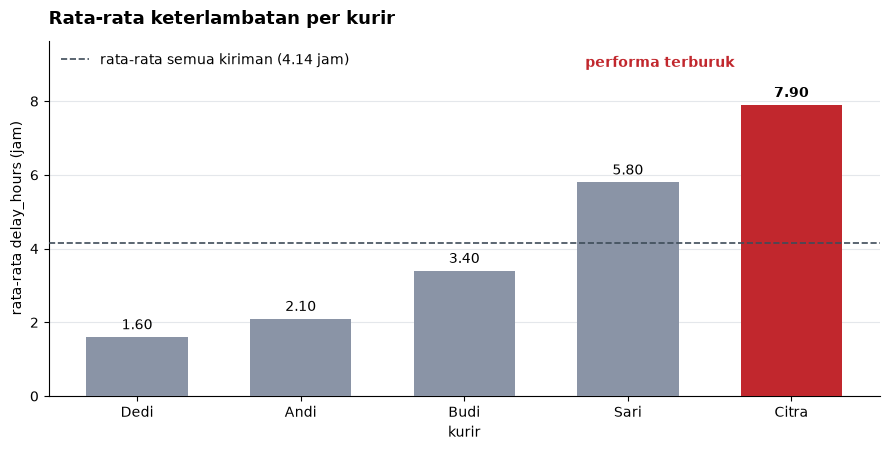

In [27]:
def gaya_sumbu(ax, judul, xlabel, ylabel):
    ax.set_title(judul, loc="left", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=10)


urut = perbandingan["groupby()"].sort_values(ascending=True)
warna = ["#C1272D" if nama == kurir_terburuk else "#8A94A6" for nama in urut.index]
rata_umum = df["delay_hours"].mean()

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(urut.index, urut.values, color=warna, width=0.62, zorder=3)
ax.axhline(
    rata_umum, color="#3E4C59", linestyle="--", linewidth=1.2, zorder=4,
    label=f"rata-rata semua kiriman ({rata_umum:.2f} jam)",
)
for i, (nama, nilai) in enumerate(urut.items()):
    bobot = "bold" if nama == kurir_terburuk else "normal"
    ax.text(i, nilai + 0.12, f"{nilai:.2f}", ha="center", va="bottom", fontsize=10, fontweight=bobot)
ax.annotate(
    "performa terburuk",
    xy=(list(urut.index).index(kurir_terburuk), urut.max()),
    xytext=(list(urut.index).index(kurir_terburuk) - 0.35, urut.max() * 1.13),
    fontsize=10,
    color="#C1272D",
    fontweight="bold",
    ha="right",
)
gaya_sumbu(ax, "Rata-rata keterlambatan per kurir", "kurir", "rata-rata delay_hours (jam)")
ax.set_ylim(0, urut.max() * 1.22)
ax.legend(frameon=False, loc="upper left", fontsize=10)
fig.tight_layout()
ax_bar = ax

### Korelasi `distance_km` dan `weight_kg` terhadap `delay_hours`

Koefisien korelasi Pearson dihitung dua cara, `np.corrcoef` dan `pandas.corr()`, lalu diberi
label kekuatan lewat kondisi agar perbandingannya terbaca.

In [28]:
fitur = ["distance_km", "weight_kg"]
korelasi = {}
for nama in fitur:
    r_numpy = float(np.corrcoef(df[nama], delay)[0, 1])
    r_pandas = float(df[nama].corr(df["delay_hours"]))
    korelasi[nama] = r_numpy
    if abs(r_numpy) >= 0.7:
        kekuatan = "kuat"
    elif abs(r_numpy) >= 0.4:
        kekuatan = "sedang"
    else:
        kekuatan = "lemah"
    print(f"{nama:<14} r = {r_numpy:+.3f} (numpy) | {r_pandas:+.3f} (pandas) | {kekuatan}")

pemenang = max(korelasi, key=lambda nama: abs(korelasi[nama]))
print()
print(f"predictor lebih kuat terhadap delay_hours: {pemenang} (|r| = {abs(korelasi[pemenang]):.3f})")
print("selisih |r| jarak vs berat:", round(abs(korelasi["distance_km"]) - abs(korelasi["weight_kg"]), 3))

distance_km    r = +0.710 (numpy) | +0.710 (pandas) | kuat
weight_kg      r = +0.220 (numpy) | +0.220 (pandas) | lemah

predictor lebih kuat terhadap delay_hours: distance_km (|r| = 0.710)
selisih |r| jarak vs berat: 0.49


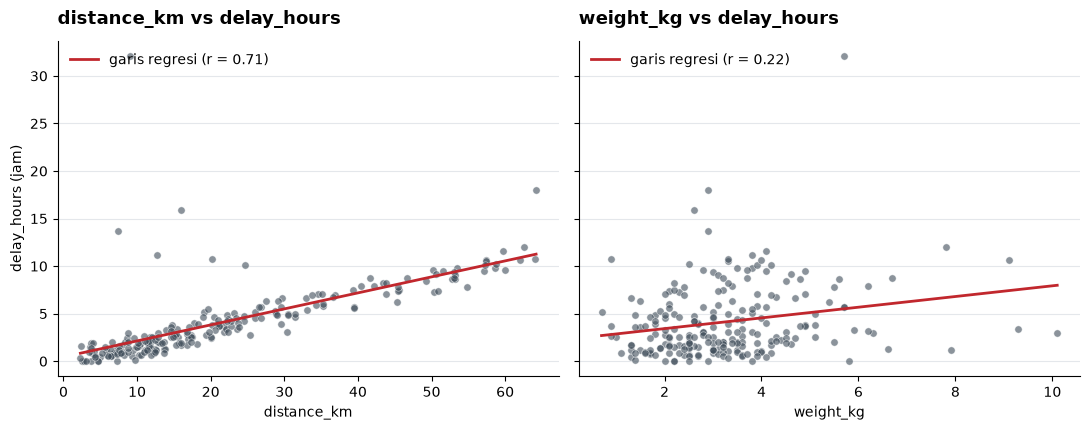

In [29]:
fig, sumbu = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
warna_titik = "#3E4C59"

for ax, nama in zip(sumbu, fitur):
    miring, potong = np.polyfit(df[nama], delay, 1)
    x_garis = np.linspace(df[nama].min(), df[nama].max(), 100)
    ax.scatter(df[nama], delay, s=28, color=warna_titik, alpha=0.6,
               edgecolor="white", linewidth=0.5, zorder=3)
    ax.plot(x_garis, miring * x_garis + potong, color="#C1272D", linewidth=2, zorder=4,
            label=f"garis regresi (r = {korelasi[nama]:.2f})")
    gaya_sumbu(ax, f"{nama} vs delay_hours", nama, "delay_hours (jam)" if ax is sumbu[0] else "")
    ax.legend(frameon=False, fontsize=10, loc="upper left")

fig.tight_layout()

## 4. Modeling: Linear Regression

Fitur model memakai variabel yang sudah diketahui saat paket diterima: jarak, berat, dan SLA
janji kirim (`promised_hours`). `actual_hours` sengaja tidak dipakai karena dia sudah berisi
jawaban akhir dan akan membuat model bocor (leakage).

Data dibagi 80/20 dengan `random_state=42` supaya hasil bisa direproduksi. Metrik evaluasi
dibandingkan dengan baseline yang selalu menebak rata-rata delay, jadi angka MAE punya acuan.

In [30]:
fitur_model = ["distance_km", "weight_kg", "promised_hours"]
X = df[fitur_model]
y = df["delay_hours"]

X_latih, X_uji, y_latih, y_uji = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_latih, y_latih)
pred_latih = model.predict(X_latih)
pred_uji = model.predict(X_uji)

def metrik(y_true, y_pred):
    return [
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred),
    ]

tabel_metrik = pd.DataFrame(
    {"data latih": metrik(y_latih, pred_latih), "data uji": metrik(y_uji, pred_uji)},
    index=["MAE (jam)", "RMSE (jam)", "R2"],
)

baseline_uji = np.full(len(y_uji), y_latih.mean())
mae_baseline = mean_absolute_error(y_uji, baseline_uji)

print(f"baris latih / uji: {len(X_latih)} / {len(X_uji)}")
print()
print(tabel_metrik.round(3).to_string())
print()
print(f"baseline (tebak rata-rata) di data uji: MAE {mae_baseline:.3f} jam")
pemangkasan = 100 * (1 - tabel_metrik.loc['MAE (jam)', 'data uji'] / mae_baseline)
print(f"model memangkas MAE sebesar {pemangkasan:.1f}% dibanding baseline")
print()
print(f"intercept: {model.intercept_:+.3f} jam")
for nama, koef in zip(fitur_model, model.coef_):
    print(f"  {nama:<14}: {koef:+.3f} jam per satu satuan")

baris latih / uji: 176 / 44

            data latih  data uji
MAE (jam)        1.062     1.102
RMSE (jam)       2.707     2.450
R2               0.507     0.524

baseline (tebak rata-rata) di data uji: MAE 2.887 jam
model memangkas MAE sebesar 61.8% dibanding baseline

intercept: +2.349 jam
  distance_km   : +0.277 jam per satu satuan
  weight_kg     : +0.235 jam per satu satuan
  promised_hours: -0.443 jam per satu satuan


### Prediksi vs kenyataan

Titik yang berdekatan dengan garis diagonal artinya prediksi meleset sedikit.

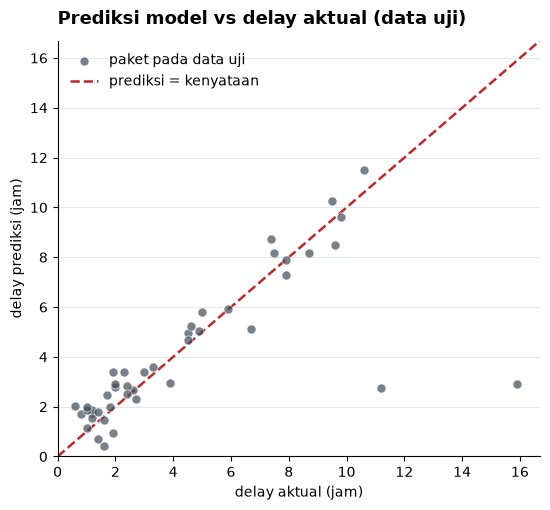

In [31]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
batas = [0, max(y_uji.max(), pred_uji.max()) * 1.05]
ax.scatter(y_uji, pred_uji, s=42, color="#3E4C59", alpha=0.7,
           edgecolor="white", linewidth=0.6, zorder=3, label="paket pada data uji")
ax.plot(batas, batas, color="#C1272D", linewidth=1.8, linestyle="--",
        label="prediksi = kenyataan")
gaya_sumbu(ax, "Prediksi model vs delay aktual (data uji)",
           "delay aktual (jam)", "delay prediksi (jam)")
ax.set_xlim(batas)
ax.set_ylim(batas)
ax.legend(frameon=False, fontsize=10, loc="upper left")
fig.tight_layout()

### Rute jauh vs rute dekat

Ambang yang dipakai: telat = `delay_hours > 2` jam, jarak jauh = `> 50` km, jarak dekat = `< 10` km.

In [32]:
BATAS_JAUH = 50
BATAS_DEKAT = 10
AMBANG_TELAT = 2

jauh = df[df["distance_km"] > BATAS_JAUH]
dekat = df[df["distance_km"] < BATAS_DEKAT]

def ringkasan(cakupan, label):
    telat = int((cakupan["delay_hours"] > AMBANG_TELAT).sum())
    return {
        "kelompok": label,
        "n": len(cakupan),
        "porsi data (%)": 100 * len(cakupan) / len(df),
        "rata-rata delay (jam)": cakupan["delay_hours"].mean(),
        "terlambat > 2 jam (n)": telat,
        "terlambat > 2 jam (%)": 100 * telat / len(cakupan),
    }

tabel_jarak = pd.DataFrame(
    [ringkasan(jauh, f"> {BATAS_JAUH} km"), ringkasan(dekat, f"< {BATAS_DEKAT} km")]
).set_index("kelompok")
print(tabel_jarak.round(2).to_string())

pct_jauh = tabel_jarak.loc[f"> {BATAS_JAUH} km", "terlambat > 2 jam (%)"]
pct_dekat = tabel_jarak.loc[f"< {BATAS_DEKAT} km", "terlambat > 2 jam (%)"]
n_jauh_telat = int(tabel_jarak.loc[f"> {BATAS_JAUH} km", "terlambat > 2 jam (n)"])
n_dekat_telat = int(tabel_jarak.loc[f"< {BATAS_DEKAT} km", "terlambat > 2 jam (n)"])
rasio = pct_jauh / pct_dekat

print()
print(f"rasio keterlambatan > {AMBANG_TELAT} jam: jauh / dekat = {rasio:.1f}x")
print("rata-rata delay: jauh",
      round(tabel_jarak.loc[f"> {BATAS_JAUH} km", "rata-rata delay (jam)"], 2), "jam vs dekat",
      round(tabel_jarak.loc[f"< {BATAS_DEKAT} km", "rata-rata delay (jam)"], 2), "jam")

           n  porsi data (%)  rata-rata delay (jam)  terlambat > 2 jam (n)  terlambat > 2 jam (%)
kelompok                                                                                         
> 50 km   24           10.91                   9.92                     24                 100.00
< 10 km   54           24.55                   1.84                      5                   9.26

rasio keterlambatan > 2 jam: jauh / dekat = 10.8x
rata-rata delay: jauh 9.92 jam vs dekat 1.84 jam


### Insight bisnis

Satu kalimat, angkanya dihasilkan dari sel di atas supaya tidak ada angka karangan.

In [33]:
insight = (
    f"Pengiriman di atas {BATAS_JAUH} km terlambat lebih dari {AMBANG_TELAT} jam pada "
    f"{pct_jauh:.1f}% kiriman ({n_jauh_telat}/{len(jauh)}), {rasio:.1f}x lebih sering daripada "
    f"pengiriman di bawah {BATAS_DEKAT} km yang hanya {pct_dekat:.1f}% "
    f"({n_dekat_telat}/{len(dekat)}), sehingga buffer jadwal dan alokasi kurir harus diprioritaskan "
    f"untuk rute di atas {BATAS_JAUH} km, bukan untuk rute dekat."
)
print(insight)

Pengiriman di atas 50 km terlambat lebih dari 2 jam pada 100.0% kiriman (24/24), 10.8x lebih sering daripada pengiriman di bawah 10 km yang hanya 9.3% (5/54), sehingga buffer jadwal dan alokasi kurir harus diprioritaskan untuk rute di atas 50 km, bukan untuk rute dekat.


> **Insight operasional**

> Pengiriman di atas 50 km terlambat lebih dari 2 jam pada 100.0% kiriman (24/24), 10.8x lebih
> sering daripada pengiriman di bawah 10 km yang hanya 9.3% (5/54), sehingga buffer jadwal dan
> alokasi kurir harus diprioritaskan untuk rute di atas 50 km, bukan untuk rute dekat.

Penjelasan singkat: `distance_km` adalah prediktor yang jauh lebih kuat (r = 0.71) dibanding
`weight_kg` (r = 0.22), dan perbedaannya terbaca langsung di lapangan, bukan hanya di koefisien.